## Problem 1:

In [ ]:
import pandas as pd

# Creating the updated dataset
data_procurement = {
    "Spare Part": [
        "45 Rymning", "Butane", "Copper rod", "drier filter", "Hydrocarbon",
        "Pin Valve", "R 22", "Relay", "Relay overload", "welding hand"
    ],

    # Updated Unit Costs
    "Unit Cost Jan-Mar": [200, 100, 30, 30, 200, 30, 550, 80, 80, 60],
    "Unit Cost Apr-Jul": [250, 150, 60, 50, 300, 60, 650, 100, 150, 120],
    "Unit Cost Aug-Dec": [200, 100, 30, 30, 200, 30, 550, 80, 80, 60],

    # Demand for 2024
    "Demand_2024_Jan_Mar": [9, 6, 9, 8, 6, 9, 14, 0, 0, 0],
    "Demand_2024_Apr_Jul": [15, 16, 26, 20, 25, 27, 30, 12, 12, 0],
    "Demand_2024_Aug_Dec": [0, 8, 7, 10, 6, 9, 11, 4, 0, 0],

    # Demand for 2023
    "Demand_2023_Jan_Mar": [6, 6, 10, 8, 9, 6, 12, 10, 6, 0],
    "Demand_2023_Apr_Jul": [12, 18, 27, 25, 28, 20, 27, 14, 13, 2],
    "Demand_2023_Aug_Dec": [1, 6, 13, 8, 11, 9, 10, 6, 8, 0],

    # Quantity Purchased
    "Quantity_Purchased_Jan_Mar": [10, 10, 15, 15, 15, 15, 20, 5, 5, 0],
    "Quantity_Purchased_Apr_Jul": [20, 20, 25, 25, 25, 25, 35, 10, 10, 2],
    "Quantity_Purchased_Aug_Dec": [10, 10, 15, 15, 15, 15, 20, 5, 5, 0],
}

# Creating DataFrame
df_procurement = pd.DataFrame(data_procurement)

# Computing descriptive statistics
df_procurement



,Spare Part,Unit Cost Jan-Mar,Unit Cost Apr-Jul,Unit Cost Aug-Dec,Demand_2024_Jan_Mar,Demand_2024_Apr_Jul,Demand_2024_Aug_Dec,Demand_2023_Jan_Mar,Demand_2023_Apr_Jul,Demand_2023_Aug_Dec,Quantity_Purchased_Jan_Mar,Quantity_Purchased_Apr_Jul,Quantity_Purchased_Aug_Dec
0,45 Rymning,200,250,200,9,15,0,6,12,1,10,20,10
1,Butane,100,150,100,6,16,8,6,18,6,10,20,10
2,Copper rod,30,60,30,9,26,7,10,27,13,15,25,15
3,drier filter,30,50,30,8,20,10,8,25,8,15,25,15
4,Hydrocarbon,200,300,200,6,25,6,9,28,11,15,25,15
5,Pin Valve,30,60,30,9,27,9,6,20,9,15,25,15
6,R 22,550,650,550,14,30,11,12,27,10,20,35,20
7,Relay,80,100,80,0,12,4,10,14,6,5,10,5
8,Relay overload,80,150,80,0,12,0,6,13,8,5,10,5
9,welding hand,60,120,60,0,0,0,0,2,0,0,2,0


<Figure size 800x500 with 0 Axes>

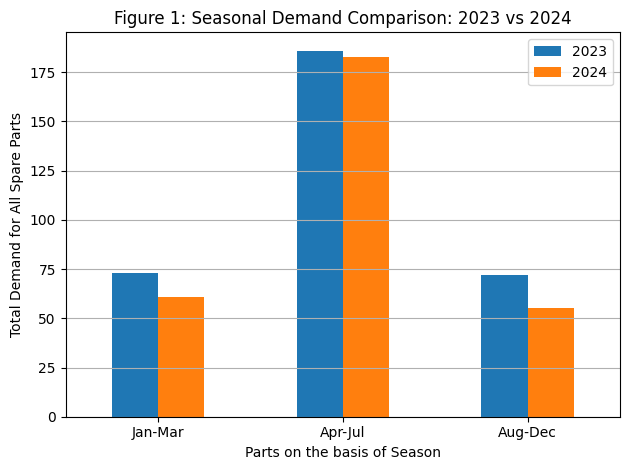

,2023,2024
Jan-Mar,73,61
Apr-Jul,186,183
Aug-Dec,72,55


In [ ]:
import matplotlib.pyplot as plt
season_labels = ["Jan-Mar", "Apr-Jul", "Aug-Dec"]

demand_2023 = df_procurement[[
    "Demand_2023_Jan_Mar",
    "Demand_2023_Apr_Jul",
    "Demand_2023_Aug_Dec"
]].sum()

demand_2024 = df_procurement[[
    "Demand_2024_Jan_Mar",
    "Demand_2024_Apr_Jul",
    "Demand_2024_Aug_Dec"
]].sum()

# Create comparison DataFrame
df_seasonal_demand = pd.DataFrame({
    "2023": demand_2023.values,
    "2024": demand_2024.values
}, index=season_labels)

# Plot
plt.figure(figsize=(8, 5))
df_seasonal_demand.plot(kind='bar', rot=0)
plt.title("Figure 1: Seasonal Demand Comparison: 2023 vs 2024")
plt.xlabel("Parts on the basis of Season")
plt.ylabel("Total Demand for All Spare Parts")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

df_seasonal_demand

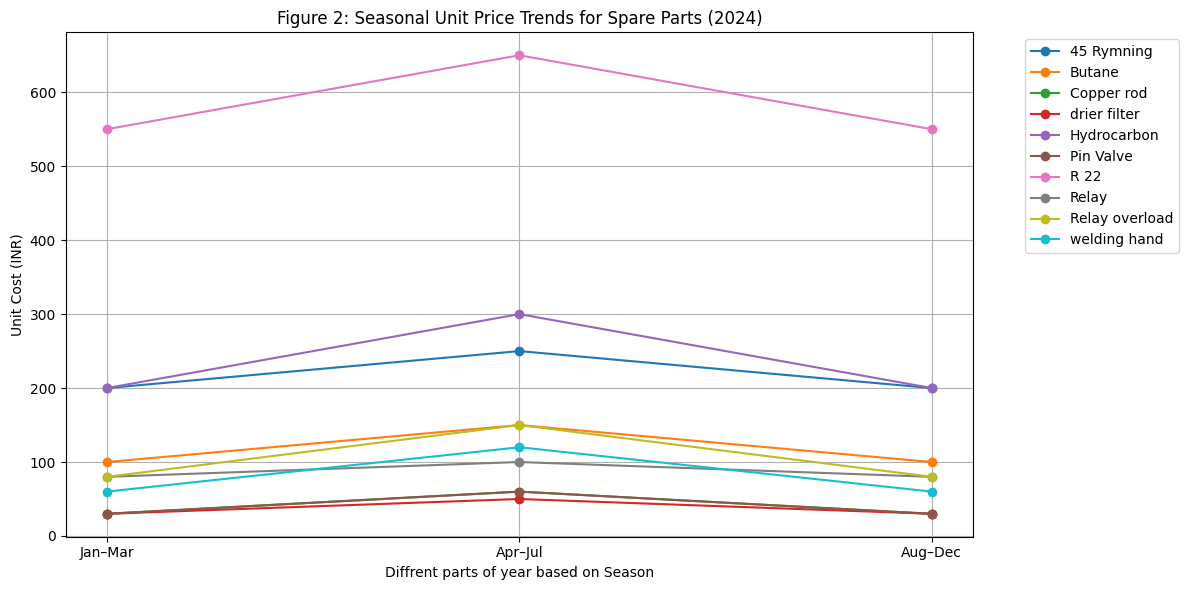

In [ ]:
# Reshape data for line plot
df_costs = df_procurement.set_index("Spare Part")[[
    "Unit Cost Jan-Mar", "Unit Cost Apr-Jul", "Unit Cost Aug-Dec"
]].T

df_costs.index = ["Jan–Mar", "Apr–Jul", "Aug–Dec"]
df_costs.index.name = "Season"

# Plot
plt.figure(figsize=(12, 6))
for part in df_costs.columns:
    plt.plot(df_costs.index, df_costs[part], marker='o', label=part)

plt.title("Figure 2: Seasonal Unit Price Trends for Spare Parts (2024)")
plt.xlabel("Diffrent parts of year based on Season")
plt.ylabel("Unit Cost (INR)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<ipython-input-6-57536267d735>:19: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ], index=pd.date_range(start="2023-01-01", periods=6, freq="Q"))


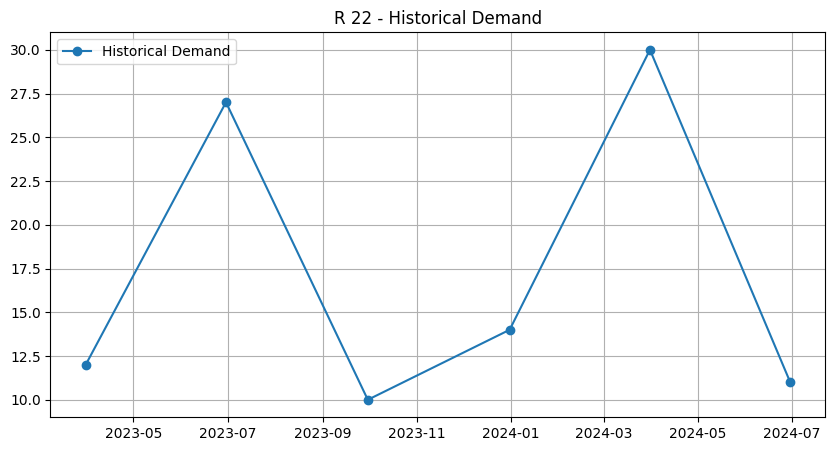

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -18.155
Date:                Thu, 10 Apr 2025   AIC                             42.310
Time:                        06:53:57   BIC                             41.138
Sample:                    03-31-2023   HQIC                            39.165
                         - 06-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5407      0.709     -0.763      0.446      -1.930       0.849
ma.L1         -0.9940    102.547     -0.010      0.992    -201.983     199.995
sigma2        47.2113   4844.687      0.010      0.9

<ipython-input-6-57536267d735>:38: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=demand_series.index[-1] + pd.offsets.QuarterEnd(), periods=2, freq='Q')


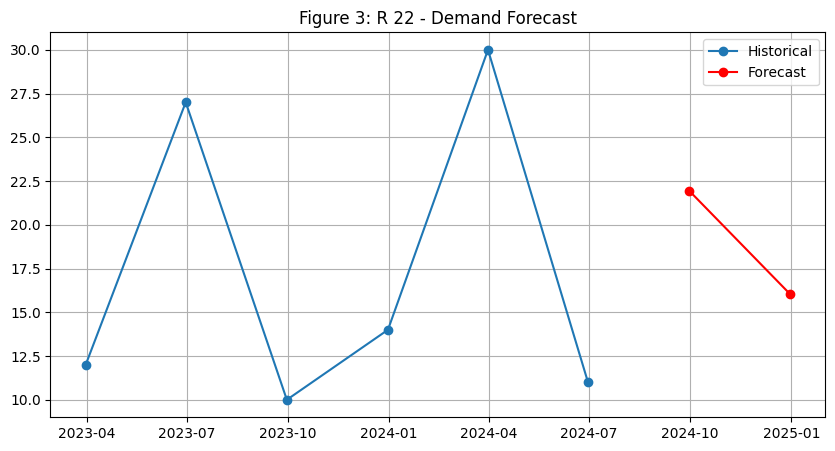

Forecasted Demand:
2024-09-30    21.948227
2024-12-31    16.028735
Freq: QE-DEC, Name: predicted_mean, dtype: float64


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import seaborn as sns

spare_part = "R 22"
row = df_procurement[df_procurement["Spare Part"] == spare_part].iloc[0]

# Build demand time series
demand_series = pd.Series([
    row["Demand_2023_Jan_Mar"],
    row["Demand_2023_Apr_Jul"],
    row["Demand_2023_Aug_Dec"],
    row["Demand_2024_Jan_Mar"],
    row["Demand_2024_Apr_Jul"],
    row["Demand_2024_Aug_Dec"]
], index=pd.date_range(start="2023-01-01", periods=6, freq="Q"))

# Plotting the historical demand
plt.figure(figsize=(10, 5))
plt.plot(demand_series, marker='o', label='Historical Demand')
plt.title(f"{spare_part} - Historical Demand")
plt.grid(True)
plt.legend()
plt.show()

# Fit ARIMA model
model = ARIMA(demand_series, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

# Forecast next 2 quarters
forecast = model_fit.forecast(steps=2)

# Plot forecast
forecast_index = pd.date_range(start=demand_series.index[-1] + pd.offsets.QuarterEnd(), periods=2, freq='Q')

plt.figure(figsize=(10, 5))
plt.plot(demand_series, marker='o', label="Historical")
plt.plot(forecast_index, forecast, marker='o', color='red', label="Forecast")
plt.title(f"Figure 3: {spare_part} - Demand Forecast")
plt.grid(True)
plt.legend()
plt.show()

print("Forecasted Demand:")
print(forecast)


In [ ]:
# Define function to compute ARIMA forecast for all spare parts
def forecast_all_spare_parts(df, spare_parts_list, steps=2):
    results = []
    for part in spare_parts_list:
        row = df[df["Spare Part"] == part].iloc[0]
        # Build demand time series
        demand_series = pd.Series([
            row["Demand_2023_Jan_Mar"],
            row["Demand_2023_Apr_Jul"],
            row["Demand_2023_Aug_Dec"],
            row["Demand_2024_Jan_Mar"],
            row["Demand_2024_Apr_Jul"],
            row["Demand_2024_Aug_Dec"]
        ], index=pd.date_range(start="2023-01-01", periods=6, freq="Q"))

        try:
            # Fit ARIMA model
            model = ARIMA(demand_series, order=(1,1,1))
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=steps)
            results.append({
                "Spare Part": part,
                "Forecast_Q1_2025": forecast.iloc[0],
                "Forecast_Q2_2025": forecast.iloc[1]
            })
        except Exception as e:
            results.append({
                "Spare Part": part,
                "Forecast_Q1_2025": None,
                "Forecast_Q2_2025": None,
                "Error": str(e)
            })
    return pd.DataFrame(results)

# List of all spare parts
spare_parts = df_procurement["Spare Part"].tolist()

# Run forecasting for all parts
forecast_results_df = forecast_all_spare_parts(df_procurement, spare_parts)
forecast_results_df

<ipython-input-4-f18b5c4700ec>:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ], index=pd.date_range(start="2023-01-01", periods=6, freq="Q"))
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
<ipython-input-4-f18b5c4700ec>:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ], index=pd.date_range(start="2023-01-01", periods=6, freq="Q"))
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting

,Spare Part,Forecast_Q1_2025,Forecast_Q2_2025
0,45 Rymning,-0.000062,-0.000062
1,Butane,7.999995,7.999995
2,Copper rod,22.337651,12.527812
3,drier filter,9.999996,9.999996
4,Hydrocarbon,19.907975,12.432215
5,Pin Valve,8.999986,8.999986
6,R 22,21.948227,16.028735
7,Relay,7.954337,7.660690
8,Relay overload,9.028404,4.143771
9,welding hand,0.000000,0.000000


## Problem 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Create DataFrame
data = {
    "Month": ["Jan 2023", "Feb 2023", "Mar 2023", "Apr 2023", "May 2023", "Jun 2023",
              "Jul 2023", "Aug 2023", "Sep 2023", "Oct 2023", "Nov 2023", "Dec 2023",
              "Jan 2024", "Feb 2024", "Mar 2024", "Apr 2024", "May 2024", "Jun 2024",
              "Jul 2024", "Aug 2024", "Sep 2024", "Oct 2024", "Nov 2024", "Dec 2024"],
    "Service Requests": [30, 62, 88, 140, 142, 103, 76, 65, 63, 68, 53, 38, 34, 53, 85,
                         130, 146, 123, 73, 52, 59, 58, 48, 36],
    "Hired Workers": [8] * 24,
    "Request Handled Per Worker": [10] * 24,
    "Required Workers": [3, 6, 9, 14, 14, 10, 8, 7, 6, 7, 5, 4, 3, 5, 9, 13, 15, 12, 7, 5,
                         6, 6, 5, 4],
    "Workers Shortage": [0, 0, 1, 6, 6, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 7, 4, 0, 0, 0, 0,
                         0, 0],
    "Workers Excess": [5, 2, 0, 0, 0, 0, 0, 2, 2, 1, 3, 4, 5, 3, 0, 0, 0, 0, 1, 3, 2, 2,
                       3, 4]
}

df = pd.DataFrame(data)

df.head(5)

,Month,Service Requests,Hired Workers,Request Handled Per Worker,Required Workers,Workers Shortage,Workers Excess
0,Jan 2023,30,8,10,3,0,5
1,Feb 2023,62,8,10,6,0,2
2,Mar 2023,88,8,10,9,1,0
3,Apr 2023,140,8,10,14,6,0
4,May 2023,142,8,10,14,6,0


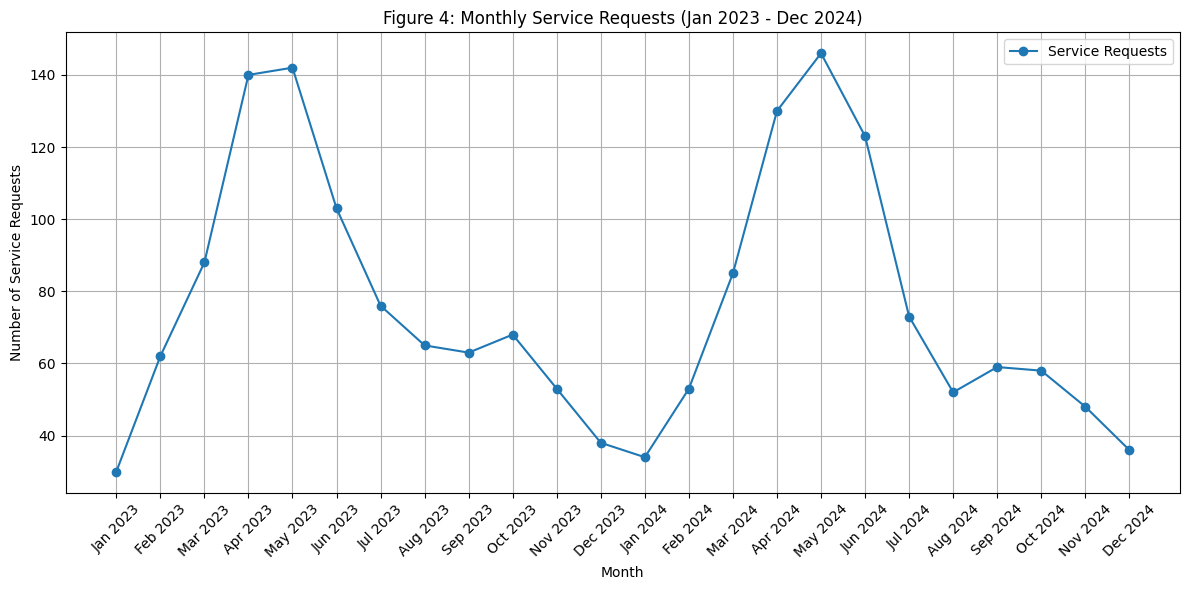

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["Month"], df["Service Requests"], marker='o', label="Service Requests")
plt.xticks(rotation=45)
plt.title("Figure 4: Monthly Service Requests (Jan 2023 - Dec 2024)")
plt.xlabel("Month")
plt.ylabel("Number of Service Requests")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


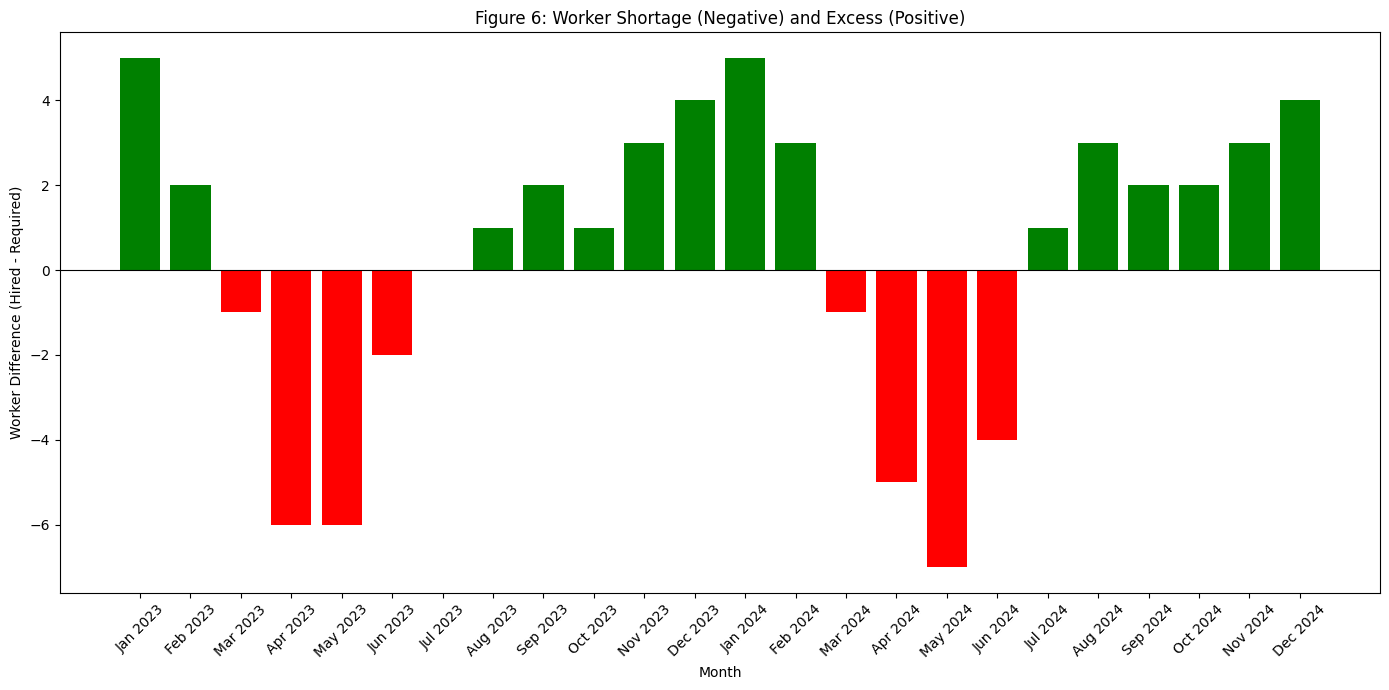

In [ ]:
# Compute worker difference: (Hired Workers - Required Workers)
df["Worker Difference"] = df["Hired Workers"] - df["Required Workers"]

# Define bar colors: red for shortages (negative), green for excess (positive), gray if zero
colors = df["Worker Difference"].apply(lambda x: "green" if x > 0 else ("red" if x < 0 else "gray"))

plt.figure(figsize=(14, 7))
plt.bar(df["Month"], df["Worker Difference"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45)
plt.title("Figure 6: Worker Shortage (Negative) and Excess (Positive)")
plt.xlabel("Month")
plt.ylabel("Worker Difference (Hired - Required)")
plt.tight_layout()
plt.show()

['Month', 'Service Requests', 'Hired Workers', 'Request Handled Per Worker', 'Required Workers', 'Workers Shortage', 'Workers Excess', 'Optimized Workers', 'Optimized Cost (INR)']


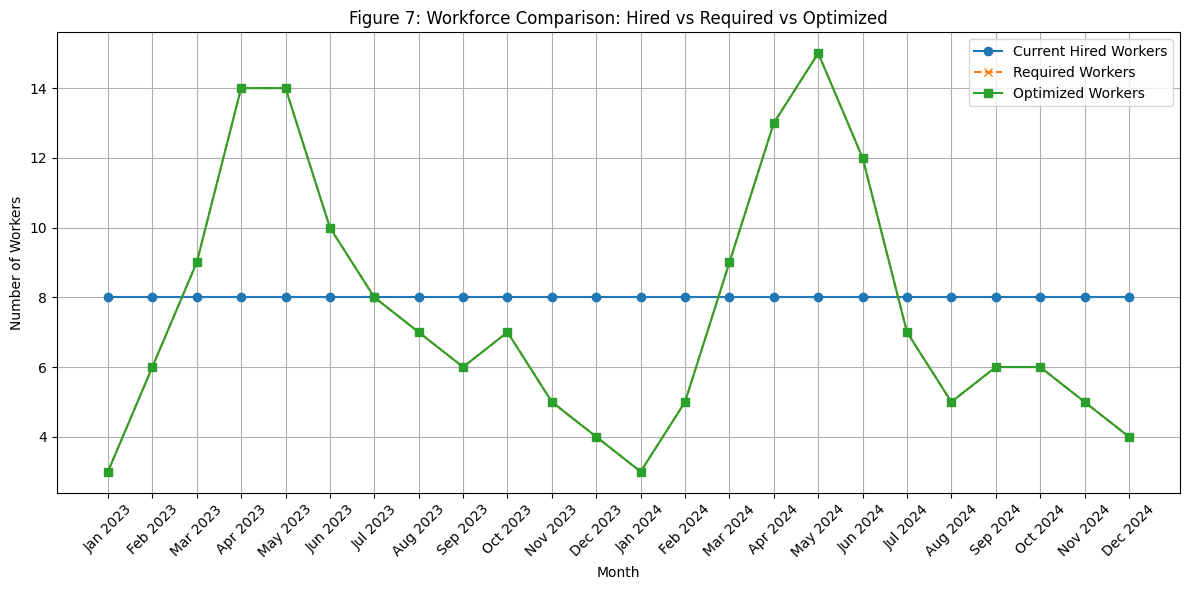

,Month,Service Requests,Required Workers,Hired Workers,Optimized Workers,Optimized Cost (INR)
0,Jan 2023,30,3,8,3,30000
1,Feb 2023,62,6,8,6,60000
2,Mar 2023,88,9,8,9,90000
3,Apr 2023,140,14,8,14,140000
4,May 2023,142,14,8,14,140000
5,Jun 2023,103,10,8,10,100000
6,Jul 2023,76,8,8,8,80000
7,Aug 2023,65,7,8,7,70000
8,Sep 2023,63,6,8,6,60000
9,Oct 2023,68,7,8,7,70000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Setting up the LP model
required_workers = df["Required Workers"].values
n_months = len(required_workers)

# Objective function: Minimize total cost (assuming Rs. 10,000 per worker per month)
cost_per_worker = 10000
c = np.ones(n_months) * cost_per_worker

# Constraints: Optimized workers must be >= required workers
A = -np.eye(n_months)
b = -required_workers

# Worker bounds (non-negative)
bounds = [(0, None) for _ in range(n_months)]

# Solve using simplex method
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

# Store results
if res.success:
    df["Optimized Workers"] = np.ceil(res.x).astype(int)
    df["Optimized Cost (INR)"] = df["Optimized Workers"] * cost_per_worker
else:
    df["Optimized Workers"] = np.nan
    df["Optimized Cost (INR)"] = np.nan

print(df.columns.tolist())

# Clean column names
df.columns = df.columns.str.strip()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Month"], df["Hired Workers"], marker='o', label="Current Hired Workers")
plt.plot(df["Month"], df["Required Workers"], marker='x', linestyle='--', label="Required Workers")
plt.plot(df["Month"], df["Optimized Workers"], marker='s', linestyle='-', label="Optimized Workers")
plt.xticks(rotation=45)
plt.title("Figure 7: Workforce Comparison: Hired vs Required vs Optimized")
plt.xlabel("Month")
plt.ylabel("Number of Workers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


df[["Month", "Service Requests", "Required Workers", "Hired Workers", "Optimized Workers", "Optimized Cost (INR)"]]


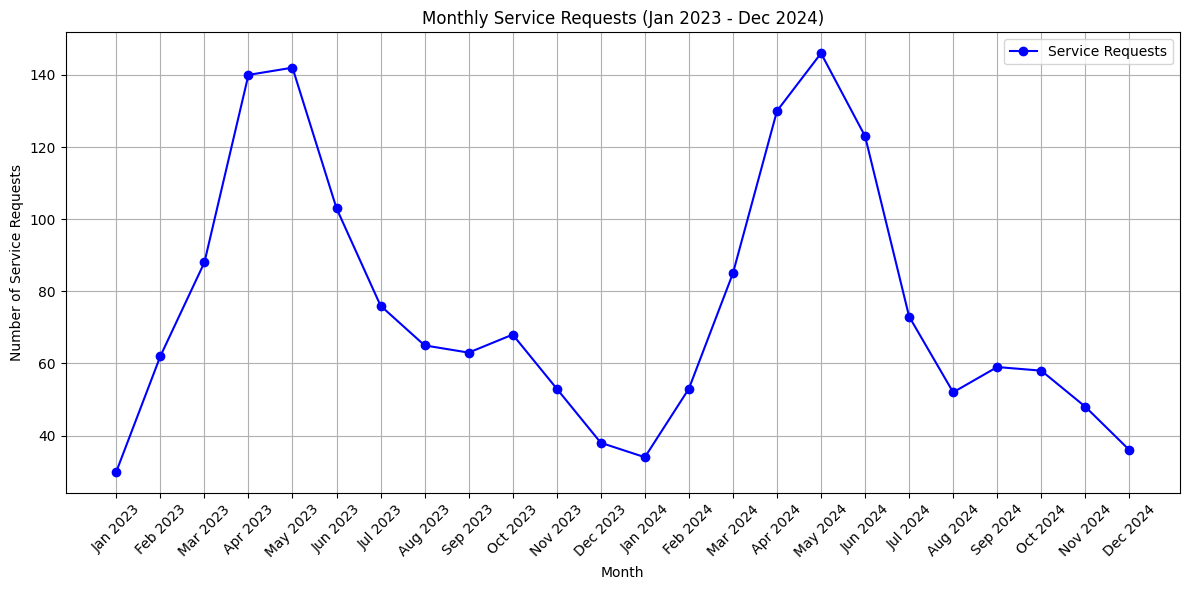

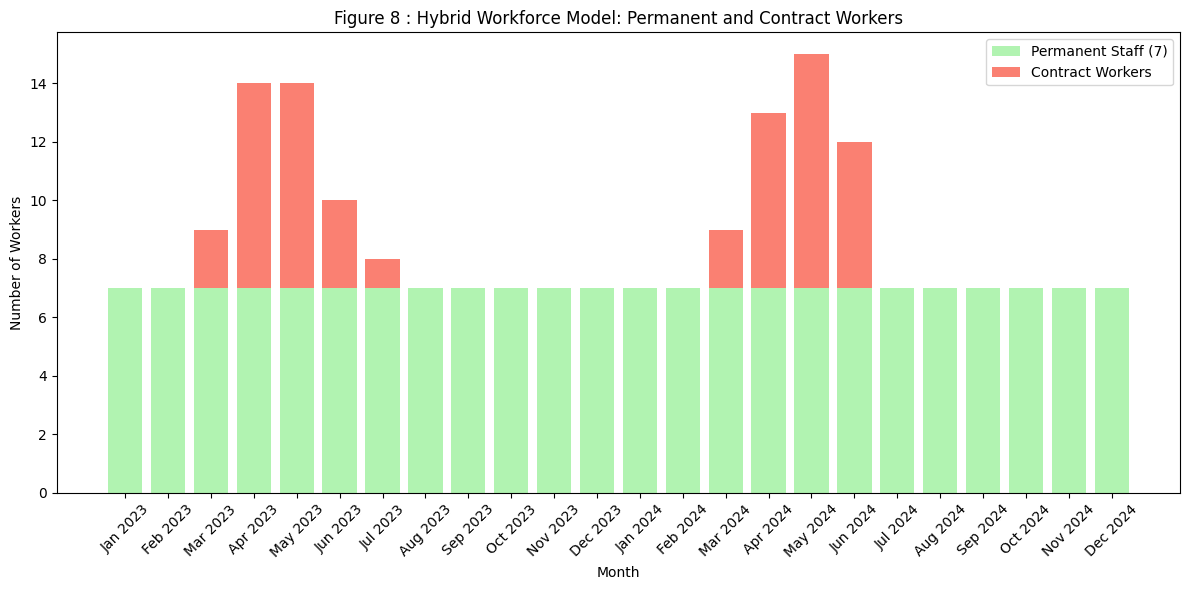

       Month  Service Requests  Required Workers  Hired Workers  \
0   Jan 2023                30                 3              8   
1   Feb 2023                62                 6              8   
2   Mar 2023                88                 9              8   
3   Apr 2023               140                14              8   
4   May 2023               142                14              8   
5   Jun 2023               103                10              8   
6   Jul 2023                76                 8              8   
7   Aug 2023                65                 7              8   
8   Sep 2023                63                 6              8   
9   Oct 2023                68                 7              8   
10  Nov 2023                53                 5              8   
11  Dec 2023                38                 4              8   
12  Jan 2024                34                 3              8   
13  Feb 2024                53                 5              

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-create the DataFrame as given
data = {
    "Month": ["Jan 2023", "Feb 2023", "Mar 2023", "Apr 2023", "May 2023", "Jun 2023",
              "Jul 2023", "Aug 2023", "Sep 2023", "Oct 2023", "Nov 2023", "Dec 2023",
              "Jan 2024", "Feb 2024", "Mar 2024", "Apr 2024", "May 2024", "Jun 2024",
              "Jul 2024", "Aug 2024", "Sep 2024", "Oct 2024", "Nov 2024", "Dec 2024"],
    "Service Requests": [30, 62, 88, 140, 142, 103, 76, 65, 63, 68, 53, 38, 34, 53, 85,
                         130, 146, 123, 73, 52, 59, 58, 48, 36],
    "Hired Workers": [8] * 24,
    "Request Handled Per Worker": [10] * 24,
    "Required Workers": [3, 6, 9, 14, 14, 10, 8, 7, 6, 7, 5, 4, 3, 5, 9, 13, 15, 12, 7, 5,
                         6, 6, 5, 4],
    "Workers Shortage": [0, 0, 1, 6, 6, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 7, 4, 0, 0, 0, 0,
                         0, 0],
    "Workers Excess": [5, 2, 0, 0, 0, 0, 0, 2, 2, 1, 3, 4, 5, 3, 0, 0, 0, 0, 1, 3, 2, 2,
                       3, 4]
}

df = pd.DataFrame(data)

# Define a baseline permanent workforce (as determined from analysis)
permanent_staff = 7

# Calculate Contract Workers needed (if Required Workers exceed permanent staff, else 0)
df["Contract Workers"] = np.maximum(df["Required Workers"] - permanent_staff, 0)

# Calculate Total Workforce for the hybrid model (should equal Required Workers ideally)
df["Total Workforce (Hybrid)"] = permanent_staff + df["Contract Workers"]

# Set the cost per worker per month (assuming the same cost for permanent and contract)
cost_per_worker = 20000

# Calculate costs
df["Permanent Cost (INR)"] = permanent_staff * cost_per_worker
df["Contract Cost (INR)"] = df["Contract Workers"] * cost_per_worker
df["Total Optimized Cost (INR)"] = df["Permanent Cost (INR)"] + df["Contract Cost (INR)"]

# --------------------- Graph 1: Monthly Service Requests Trend ---------------------
plt.figure(figsize=(12, 6))
plt.plot(df["Month"], df["Service Requests"], marker='o', linestyle='-', color='blue', label="Service Requests")
plt.xticks(rotation=45)
plt.title("Monthly Service Requests (Jan 2023 - Dec 2024)")
plt.xlabel("Month")
plt.ylabel("Number of Service Requests")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------- Graph 2: Comparison of Permanent, Contract, and Total Workforce ---------------------
plt.figure(figsize=(12, 6))
# Plot permanent workers as a constant baseline
plt.bar(df["Month"], [permanent_staff]*len(df), color='lightgreen', label="Permanent Staff (7)", alpha=0.7)
# Plot contract workers on top of the permanent staff (stacked)
plt.bar(df["Month"], df["Contract Workers"], bottom=[permanent_staff]*len(df), color='salmon', label="Contract Workers")
plt.xticks(rotation=45)
plt.title("Figure 8 : Hybrid Workforce Model: Permanent and Contract Workers")
plt.xlabel("Month")
plt.ylabel("Number of Workers")
plt.legend()
plt.tight_layout()
plt.show()

# Optionally, display the DataFrame with the new columns
print(df[["Month", "Service Requests", "Required Workers", "Hired Workers", "Contract Workers",
          "Total Workforce (Hybrid)", "Total Optimized Cost (INR)"]])
